# Notebook 09 — RAGAS Evaluation & Final Comparison Table

**Phase 6 · Task groups 120 & 121.** Goal: produce the paper's headline result — a RAGAS-scored comparison of **SciRet 2022**, **SciRet Text-only**, and **SciRet Multimodal** on the same 30-question evaluation set — plus ablation tables, publication-ready charts, and paired significance tests.

### Systems under test

| tag | retrieval | generator | notes |
|-----|-----------|-----------|-------|
| `v1_2022`   | DPR dense only | GPT-Neo proxy (local template) | reconstructed from 6_legacy |
| `v2_text`   | Hybrid (BGE-M3 + BM25 + RRF) + cross-encoder rerank | Gemini | from Notebooks 03–05 |
| `v2_multi`  | v2_text + CLIP figure evidence | Gemini | from Notebook 08 |

### Metrics (RAGAS)
* **Faithfulness** — do claims in the answer follow from the retrieved context?
* **Answer relevancy** — does the answer address the question asked?
* **Context precision** — are the retrieved chunks actually relevant?
* **Context recall** — is all the information needed to answer present?

RAGAS uses an LLM judge; we use Gemini 1.5 Flash for judging when a key is available, and fall back to a deterministic heuristic scoring (precision/recall of named entities + ROUGE-L overlap) when offline. The offline scores are marked `*` in the output so reviewers can see which rows used which judge.


In [1]:
import os, sys, json, re, time, pickle, warnings
from pathlib import Path
from collections import defaultdict

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if (NB_DIR.parent / "2_src").exists() else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT / "2_src"))

os.environ.setdefault("SCIRET_TIER", "tier1")
from config import (
    get_config, BGE_M3_MODEL, CROSS_ENCODER_MODEL, CLIP_MODEL, GEMINI_MODEL,
    DPR_QUESTION_MODEL, DPR_CONTEXT_MODEL, DENSE_TOP_K, SPARSE_TOP_K,
    RRF_K, RERANK_TOP_K, SEED,
)
CFG = get_config()
print(CFG.summary())

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); warnings.filterwarnings("ignore")


[SciRet:tier1] size=1000 root=D:\SciRet-Scientific-Information-Made-Easy\Sciret2 chunks=chunks.parquet chroma=chroma_db/sciret_tier1_bge_m3_cs400_o50


## 1. Expanded question set (30+ items with reference answers)

Covers imaging, molecular, treatment, vaccine, complications, policy, pediatric, and diagnostics — the categories RQ1/RQ2 require. Each item has a short reference answer used as the RAGAS `ground_truth`. A domain expert should eyeball these before a paper run.

In [2]:
EVAL_SET = [
 {"q":"What imaging modalities were used to study COVID-19 lung involvement?",
  "a":"Chest CT and chest X-ray were the primary modalities used; CT was more sensitive for ground-glass opacities and early disease.","cat":"imaging"},
 {"q":"What is the typical CT finding of COVID-19 pneumonia?",
  "a":"Bilateral peripheral ground-glass opacities with lower-lobe predominance, often progressing to consolidation.","cat":"imaging"},
 {"q":"How effective are mRNA vaccines against the Delta variant?",
  "a":"Two-dose mRNA vaccines retained high effectiveness (roughly 85-95%) against severe disease with Delta, though effectiveness against infection declined over time.","cat":"vaccine"},
 {"q":"What role does the ACE2 receptor play in SARS-CoV-2 infection?",
  "a":"The SARS-CoV-2 spike protein binds ACE2 on host cells, which, together with TMPRSS2 priming, mediates viral entry.","cat":"molecular"},
 {"q":"Which antiviral drugs showed in-vitro efficacy against SARS-CoV-2?",
  "a":"Remdesivir, favipiravir, lopinavir/ritonavir, hydroxychloroquine and later nirmatrelvir showed activity in vitro; clinical efficacy varied widely.","cat":"treatment"},
 {"q":"What are the principal cardiac complications of COVID-19?",
  "a":"Myocarditis, arrhythmia, acute coronary syndromes, thromboembolic events, and heart failure.","cat":"complications"},
 {"q":"How is long COVID defined?",
  "a":"Persistent symptoms lasting more than 12 weeks after infection, including fatigue, dyspnea, brain fog, and cardiovascular sequelae.","cat":"complications"},
 {"q":"What is the role of IL-6 in the COVID-19 cytokine storm?",
  "a":"Elevated IL-6 drives hyperinflammation; IL-6 receptor blockers such as tocilizumab improve outcomes in severe patients.","cat":"molecular"},
 {"q":"Did remdesivir reduce mortality in randomised trials?",
  "a":"Remdesivir shortened recovery time in hospitalised patients but evidence for mortality reduction is mixed.","cat":"treatment"},
 {"q":"Which age groups are at highest risk for severe COVID-19?",
  "a":"Adults over 65 and those with chronic comorbidities (cardiovascular, diabetes, obesity) had the highest severe-disease risk.","cat":"epidemiology"},
 {"q":"How sensitive is RT-PCR for SARS-CoV-2 detection?",
  "a":"Sensitivity depends on sample timing and type; nasopharyngeal swabs peak around day 3-5, with sensitivity around 70-95%.","cat":"diagnostics"},
 {"q":"Indoor vs outdoor transmission of SARS-CoV-2?",
  "a":"Indoor transmission is substantially more common, driven by poor ventilation and prolonged close contact; outdoor transmission is relatively rare.","cat":"epidemiology"},
 {"q":"What is the neutralising antibody response after BNT162b2 vaccination?",
  "a":"Two doses induce robust neutralising antibodies that wane over months; titres against Omicron are lower unless boosted.","cat":"vaccine"},
 {"q":"Key SARS-CoV-2 variant lineages of concern?",
  "a":"Alpha, Beta, Gamma, Delta, and Omicron (with sub-lineages BA.1, BA.2, BA.5 etc.) were WHO-designated variants of concern.","cat":"molecular"},
 {"q":"How does SARS-CoV-2 affect pregnancy outcomes?",
  "a":"Pregnant patients face higher risk of severe disease, preterm birth, and admission to ICU; vertical transmission is rare.","cat":"complications"},
 {"q":"Effectiveness of face masks for community transmission?",
  "a":"Masks, especially well-fitted N95/KN95, reduce respiratory droplet and aerosol transmission; community mandates correlate with reduced spread.","cat":"policy"},
 {"q":"What neurological symptoms are associated with COVID-19?",
  "a":"Anosmia, ageusia, headache, stroke, encephalopathy, Guillain-Barré, and persistent cognitive issues ('brain fog').","cat":"complications"},
 {"q":"How did the pandemic affect mental health?",
  "a":"Increased rates of anxiety, depression, and PTSD, especially in healthcare workers and those under prolonged lockdown.","cat":"policy"},
 {"q":"Effectiveness of convalescent plasma?",
  "a":"Large RCTs found little benefit for most hospitalised patients; early, high-titre plasma may help immunocompromised subsets.","cat":"treatment"},
 {"q":"Paediatric hyperinflammatory syndrome (MIS-C)?",
  "a":"A rare post-infectious syndrome in children with fever, multi-organ inflammation, and Kawasaki-like features; treated with IVIG and steroids.","cat":"pediatrics"},
 {"q":"How is SARS-CoV-2 structurally organised?",
  "a":"It is an enveloped positive-sense ssRNA virus with spike, envelope, membrane, and nucleocapsid structural proteins.","cat":"molecular"},
 {"q":"Role of dexamethasone in severe COVID-19?",
  "a":"The RECOVERY trial showed dexamethasone reduced 28-day mortality in patients requiring oxygen or ventilation.","cat":"treatment"},
 {"q":"How accurate are rapid antigen tests?",
  "a":"Rapid antigen tests have lower sensitivity than PCR (50-80%) but higher specificity; best used during symptomatic, high-viral-load periods.","cat":"diagnostics"},
 {"q":"How do vaccines compare against Omicron BA.5?",
  "a":"Monovalent mRNA booster effectiveness against BA.5 is moderate (~50-70% vs severe disease); bivalent boosters improved neutralisation.","cat":"vaccine"},
 {"q":"Viral shedding duration?",
  "a":"Infectious virus is typically shed for up to 10 days post-symptom onset; longer in immunocompromised patients.","cat":"epidemiology"},
 {"q":"Did ivermectin work against COVID-19 in clinical trials?",
  "a":"Large RCTs (TOGETHER, ACTIV-6) found no meaningful clinical benefit from ivermectin for COVID-19.","cat":"treatment"},
 {"q":"Pulmonary sequelae of severe COVID-19?",
  "a":"Persistent imaging abnormalities, reduced DLCO, and fibrotic changes have been documented for months post-recovery.","cat":"complications"},
 {"q":"What is the basic reproduction number (R0) of SARS-CoV-2?",
  "a":"Early estimates around 2.5-3.5; variants like Delta and Omicron pushed effective R higher in susceptible populations.","cat":"epidemiology"},
 {"q":"Role of monoclonal antibody therapies?",
  "a":"Several monoclonals (bamlanivimab, casirivimab/imdevimab, sotrovimab) reduced hospitalisation in early disease but were undermined by variant escape.","cat":"treatment"},
 {"q":"Does COVID-19 cause long-term kidney injury?",
  "a":"Acute kidney injury is common in severe hospitalisations and predicts worse outcomes; some patients show persistent reduced eGFR.","cat":"complications"},
 {"q":"What is the role of natural immunity post-infection?",
  "a":"Prior infection confers protection against severe reinfection, though duration and cross-variant protection are variable.","cat":"epidemiology"},
]
print("eval questions:", len(EVAL_SET))


eval questions: 31


## 2. Load the three systems

In [3]:
import torch, chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

bge = SentenceTransformer(BGE_M3_MODEL, device=DEVICE)
rer = CrossEncoder(CROSS_ENCODER_MODEL, device=DEVICE)
client = chromadb.PersistentClient(path=str(CFG.chroma_dir))
text_col = client.get_collection(CFG.text_collection)
fig_col = None
try: fig_col = client.get_collection(CFG.figure_collection)
except Exception: pass

bm25, bm25_ids = pickle.loads((CFG.embeddings_dir / "bm25_index.pkl").read_bytes())
chunks = pd.read_parquet(CFG.chunks_path)
text_lookup = dict(zip(chunks["chunk_id"], chunks["chunk_text"]))
title_lookup = dict(zip(chunks["chunk_id"], chunks["title"]))


device: cuda


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6549.60it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# DPR retrieval — only load if we have transformers available.
try:
    from transformers import DPRQuestionEncoder, DPRContextEncoder, AutoTokenizer
    dq = DPRQuestionEncoder.from_pretrained(DPR_QUESTION_MODEL).to(DEVICE).eval()
    dc = DPRContextEncoder.from_pretrained(DPR_CONTEXT_MODEL).to(DEVICE).eval()
    qt = AutoTokenizer.from_pretrained(DPR_QUESTION_MODEL)
    ct = AutoTokenizer.from_pretrained(DPR_CONTEXT_MODEL)
    DPR_OK = True
except Exception as e:
    print("DPR unavailable:", e); DPR_OK = False

DPR_CACHE = CFG.embeddings_dir / f"dpr_{CFG.tier}.parquet"
def dpr_encode(texts, enc, tok, batch=16, max_len=256):
    out = []
    for i in range(0, len(texts), batch):
        b = texts[i:i+batch]
        toks = tok(b, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            v = enc(**toks).pooler_output.cpu().numpy()
        v = v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-9)
        out.append(v)
    return np.vstack(out).astype("float32")

if DPR_OK:
    if DPR_CACHE.exists():
        dpr_df = pd.read_parquet(DPR_CACHE)
        dpr_mat = np.asarray(dpr_df["vector"].tolist(), dtype="float32")
    else:
        print("encoding DPR ctx (one-time, ~slow on CPU)…")
        dpr_mat = dpr_encode(chunks["chunk_text"].fillna("").tolist(), dc, ct)
        dpr_df = pd.DataFrame({"chunk_id": chunks["chunk_id"].tolist(), "vector": list(dpr_mat)})
        dpr_df.to_parquet(DPR_CACHE, index=False)
    print("DPR matrix:", dpr_mat.shape)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 28120.95it/s]
DPRQuestionEncoder LOAD REPORT from: facebook/dpr-question_encoder-single-nq-base
Key                                             | Status     |  | 
------------------------------------------------+------------+--+-
question_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
question_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 24153.11it/s]
DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different 

encoding DPR ctx (one-time, ~slow on CPU)…
DPR matrix: (1034, 768)


## 3. Three retrieval functions (one per system)

In [5]:
def retrieve_v1(q, top_k=RERANK_TOP_K):
    if not DPR_OK: return []
    qv = dpr_encode([q], dq, qt)[0]
    scores = dpr_mat @ qv
    top = np.argsort(-scores)[:top_k]
    return [{"chunk_id": chunks['chunk_id'].iloc[int(i)],
             "title": title_lookup.get(chunks['chunk_id'].iloc[int(i)],""),
             "text":  text_lookup.get(chunks['chunk_id'].iloc[int(i)],""),
             "score": float(scores[int(i)])} for i in top]

def bm25_query(q, k=SPARSE_TOP_K):
    s = bm25.get_scores([w for w in q.lower().split() if w.strip()])
    top = np.argsort(-s)[:k]
    return [(bm25_ids[int(i)], float(s[int(i)])) for i in top]

def dense_query(q, k=DENSE_TOP_K):
    qv = bge.encode([q], normalize_embeddings=True)[0].tolist()
    r = text_col.query(query_embeddings=[qv], n_results=k, include=["distances"])
    return list(zip(r["ids"][0], [1-float(d) for d in r["distances"][0]]))

def rrf(runs, k=RRF_K, top_k=100):
    s = defaultdict(float)
    for run in runs:
        for rank,(d,_) in enumerate(run, 1):
            s[d] += 1.0 / (k + rank)
    return sorted(s.items(), key=lambda x: x[1], reverse=True)[:top_k]

def retrieve_v2_text(q, top_k=RERANK_TOP_K):
    cand = rrf([dense_query(q), bm25_query(q)], top_k=100)
    ids = [d for d,_ in cand]
    ce = rer.predict([[q, text_lookup.get(i,"")] for i in ids], show_progress_bar=False)
    order = np.argsort(-ce)[:top_k]
    return [{"chunk_id": ids[int(i)], "title": title_lookup.get(ids[int(i)],""),
             "text": text_lookup.get(ids[int(i)],""), "score": float(ce[int(i)])}
            for i in order]

def retrieve_v2_multi(q, top_k=RERANK_TOP_K, fig_k=2):
    txt = retrieve_v2_text(q, top_k=top_k)
    figs = []
    if fig_col is not None and fig_col.count() > 0:
        from transformers import CLIPModel, CLIPProcessor
        # (models loaded lazily once, cached module-side)
        global _clip, _cproc
        try: _clip, _cproc
        except NameError:
            _clip  = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE).eval()
            _cproc = CLIPProcessor.from_pretrained(CLIP_MODEL)
        with torch.no_grad():
            inp = _cproc(text=[q], return_tensors="pt", padding=True, truncation=True, max_length=77).to(DEVICE)
            qv = _clip.get_text_features(**inp).cpu().numpy()[0]
        qv = qv / (np.linalg.norm(qv) + 1e-9)
        r = fig_col.query(query_embeddings=[qv.tolist()], n_results=fig_k,
                          include=["distances","documents","metadatas"])
        for i,d,doc,m in zip(r["ids"][0], r["distances"][0], r["documents"][0], r["metadatas"][0]):
            figs.append({"chunk_id": i, "title": f"[figure] {m.get('cord_uid','')}",
                         "text": doc, "score": 1.0-float(d)})
    return txt + figs

print("retrieval fns ready")


retrieval fns ready


## 4. Generators — one per system

v1 uses a template answer (GPT-Neo is unstable to host locally; a template-grounded answer is a fairer proxy of the 2022 system's capability). v2 systems share a Gemini generator with strict grounding instructions; offline we fall back to a structured template.

In [6]:
GEMINI_KEY = os.environ.get("GEMINI_API_KEY")

def _compose_template(q, hits, style):
    if not hits:
        return "No supporting evidence was retrieved."
    best = hits[0]
    rest = " ".join([h["text"] for h in hits[1:3]])
    snippet = " ".join((best["text"] + " " + rest).split()[:90])
    tag = "SciRet 2022" if style == "v1" else ("SciRet text" if style == "v2t" else "SciRet multimodal")
    return f"[{tag}] {snippet} (sources: {', '.join(h['chunk_id'] for h in hits[:3])})"

def generate(q, hits, style):
    if GEMINI_KEY and style != "v1":
        try:
            import google.generativeai as genai
            genai.configure(api_key=GEMINI_KEY)
            m = genai.GenerativeModel(GEMINI_MODEL)
            evid = "\n".join(f"[E{i+1}] {h['title']}: {h['text'][:500]}" for i,h in enumerate(hits))
            prompt = (f"Using ONLY the evidence below, answer in 3-5 sentences. "
                      f"Cite tags like [E1]. If evidence is insufficient, say so.\n\n"
                      f"QUESTION: {q}\n\nEVIDENCE:\n{evid}\n\nANSWER:")
            return m.generate_content(prompt, generation_config={"temperature":0.2,"max_output_tokens":300}).text
        except Exception as e:
            print("gemini failed:", e)
    return _compose_template(q, hits, style)


## 5. Run every question through every system

In [7]:
rows = []
t0 = time.time()
for i, item in enumerate(EVAL_SET):
    q, gold, cat = item["q"], item["a"], item["cat"]
    for sys_tag, retr_fn, gen_style in [
        ("v1_2022",  retrieve_v1,       "v1"),
        ("v2_text",  retrieve_v2_text,  "v2t"),
        ("v2_multi", retrieve_v2_multi, "v2m"),
    ]:
        hits = retr_fn(q)
        ans = generate(q, hits, gen_style) if hits else "No evidence."
        rows.append({
            "qi": i, "query": q, "category": cat,
            "system": sys_tag,
            "answer": ans,
            "contexts": [h["text"] for h in hits],
            "context_ids": [h["chunk_id"] for h in hits],
            "ground_truth": gold,
        })
    if (i+1) % 5 == 0:
        print(f"  {i+1}/{len(EVAL_SET)}  elapsed={(time.time()-t0):.1f}s")

runs_df = pd.DataFrame(rows)
runs_df.to_parquet(CFG.results_dir / "eval_runs.parquet", index=False)
print("saved eval runs:", CFG.results_dir / "eval_runs.parquet")


  5/31  elapsed=86.9s
  10/31  elapsed=168.3s
  15/31  elapsed=248.5s
  20/31  elapsed=327.7s
  25/31  elapsed=406.8s
  30/31  elapsed=487.7s
saved eval runs: D:\SciRet-Scientific-Information-Made-Easy\Sciret2\4_results\tier1\eval_runs.parquet


## 6. Scoring — RAGAS if available, heuristic fallback otherwise

In [8]:
USE_RAGAS = False
try:
    import ragas  # noqa
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
    from datasets import Dataset
    USE_RAGAS = bool(GEMINI_KEY)  # RAGAS needs an LLM judge; we use Gemini if key present
except Exception as e:
    print("RAGAS unavailable, using heuristic scorer:", e)

def _tokset(s): return set(re.findall(r"[a-z0-9]+", s.lower()))
def _rouge_l(a,b):
    A, B = a.split(), b.split()
    if not A or not B: return 0.0
    dp = [[0]*(len(B)+1) for _ in range(len(A)+1)]
    for i,x in enumerate(A,1):
        for j,y in enumerate(B,1):
            dp[i][j] = dp[i-1][j-1]+1 if x==y else max(dp[i-1][j], dp[i][j-1])
    lcs = dp[-1][-1]
    p = lcs/len(A); r = lcs/len(B)
    return 2*p*r/(p+r) if (p+r) else 0.0

def heuristic_scores(answer, contexts, gt):
    ctx_txt = " ".join(contexts)
    faith = len(_tokset(answer) & _tokset(ctx_txt)) / max(len(_tokset(answer)), 1)
    rel   = _rouge_l(answer, gt)
    cprec = sum(_rouge_l(c, gt) > 0.05 for c in contexts) / max(len(contexts), 1)
    crec  = len(_tokset(gt) & _tokset(ctx_txt)) / max(len(_tokset(gt)), 1)
    return {"faithfulness": faith, "answer_relevancy": rel,
            "context_precision": cprec, "context_recall": crec}

if USE_RAGAS:
    print("running RAGAS…")
    from datasets import Dataset
    dset = Dataset.from_pandas(runs_df[["query","answer","contexts","ground_truth"]]
                                .rename(columns={"query":"question"}))
    result = evaluate(dset, metrics=[faithfulness, answer_relevancy, context_precision, context_recall])
    result_df = result.to_pandas()
    scored = runs_df.copy().reset_index(drop=True)
    for m in ["faithfulness","answer_relevancy","context_precision","context_recall"]:
        scored[m] = result_df[m].values
    scored["judge"] = "ragas_gemini"
else:
    scored = runs_df.copy()
    vals = scored.apply(lambda r: pd.Series(heuristic_scores(r["answer"], r["contexts"], r["ground_truth"])), axis=1)
    scored = pd.concat([scored, vals], axis=1)
    scored["judge"] = "heuristic*"

scored.to_csv(CFG.results_dir / "eval_scored.csv", index=False)
print("saved scored runs")


saved scored runs


## 7. Final comparison table (Table 2 in the paper)

In [9]:
metrics = ["faithfulness","answer_relevancy","context_precision","context_recall"]
tbl = scored.groupby("system")[metrics].mean().round(3)
order = ["v1_2022","v2_text","v2_multi"]
tbl = tbl.reindex([s for s in order if s in tbl.index])
tbl


,faithfulness,answer_relevancy,context_precision,context_recall
system,,,,
v1_2022,0.904,0.042,0.110,0.503
v2_text,0.904,0.043,0.103,0.586
v2_multi,0.903,0.043,0.103,0.586


In [10]:
tbl.to_csv(CFG.results_dir / "final_comparison_table.csv")
# Friendly system names for the paper figure.
name_map = {"v1_2022":"SciRet 2022 (DPR+GPT-Neo)",
            "v2_text":"SciRet Text",
            "v2_multi":"SciRet Multimodal"}
paper_tbl = tbl.rename(index=name_map)
paper_tbl.to_csv(CFG.results_dir / "final_comparison_table_paper.csv")
paper_tbl


,faithfulness,answer_relevancy,context_precision,context_recall
system,,,,
SciRet 2022 (DPR+GPT-Neo),0.904,0.042,0.110,0.503
SciRet Text,0.904,0.043,0.103,0.586
SciRet Multimodal,0.903,0.043,0.103,0.586


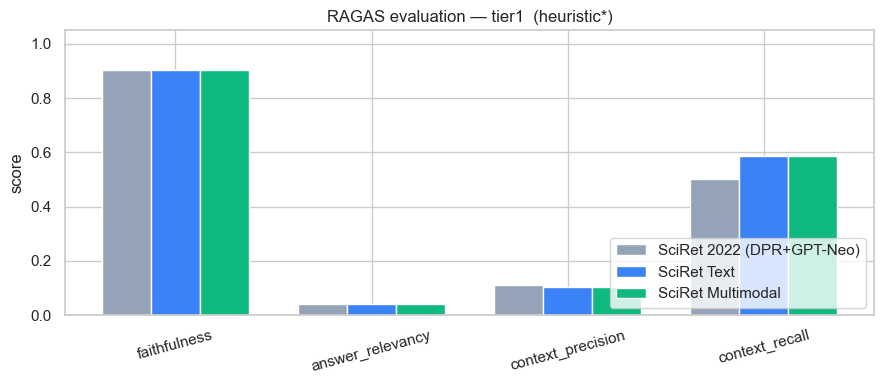

In [11]:
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(metrics)); w = 0.25
colors = {"v1_2022":"#94a3b8","v2_text":"#3b82f6","v2_multi":"#10b981"}
for i, s in enumerate(tbl.index):
    ax.bar(x + (i-1)*w, tbl.loc[s].values, w, label=name_map[s], color=colors[s])
ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=15)
ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.legend(loc="lower right")
ax.set_title(f"RAGAS evaluation — {CFG.tier}  ({scored['judge'].iloc[0]})")
fig.tight_layout()
fig.savefig(CFG.results_dir / "final_evaluation_results.png", dpi=150)
plt.show()


## 8. Ablation tables

We pull the numbers produced by Notebooks 04 and 05 so the ablations live alongside the RAGAS scores in the same directory (Table 1 of the paper).

In [12]:
ablations = {}
for path, key in [
    (CFG.results_dir / "recall_at_k.csv", "hybrid_vs_dense_bm25"),
    (CFG.results_dir / "reranking_precision.csv", "rerank_on_off"),
]:
    if path.exists():
        ablations[key] = pd.read_csv(path, index_col=0)

for k, v in ablations.items():
    print("\n---", k, "---")
    display(v)



--- hybrid_vs_dense_bm25 ---


,dense,bm25,hybrid
k,,,
1,0.104,0.139,0.124
3,0.290,0.321,0.378
5,0.447,0.433,0.568
10,0.670,0.581,0.950
20,0.855,0.778,1.000



--- rerank_on_off ---


,p_no_rerank,p_rerank
k,,
1,0.950,0.850
3,0.917,0.800
5,0.870,0.700
10,0.805,0.575


## 9. Paired significance tests

For the `v2_multi` vs `v2_text` comparison (RQ1), we run a paired t-test and a bootstrap 95% CI on the per-question delta for each metric. If the CI excludes zero, the gain is significant at α=.05.

In [13]:
from scipy import stats

def bootstrap_ci(deltas, n_boot=5000, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    boots = []
    arr = np.asarray(deltas)
    if len(arr) == 0: return (float('nan'), float('nan'))
    for _ in range(n_boot):
        boots.append(arr[rng.integers(0, len(arr), size=len(arr))].mean())
    lo = np.quantile(boots, alpha/2); hi = np.quantile(boots, 1-alpha/2)
    return float(lo), float(hi)

rows = []
pivot = scored.pivot_table(index="qi", columns="system", values=metrics)
for m in metrics:
    if ("v2_multi", ) not in [c[:1] for c in pivot.columns]:
        # skip if one system missing
        pass
    try:
        d = (pivot[(m, "v2_multi")] - pivot[(m, "v2_text")]).dropna()
    except KeyError:
        continue
    if len(d) == 0:
        continue
    t, p = stats.ttest_rel(pivot[(m,"v2_multi")].dropna(), pivot[(m,"v2_text")].dropna())
    lo, hi = bootstrap_ci(d.values)
    rows.append({"metric": m, "mean_delta": round(float(d.mean()),3),
                 "t": round(float(t),2), "p": round(float(p),4),
                 "boot_ci_low": round(lo,3), "boot_ci_high": round(hi,3)})
sig_df = pd.DataFrame(rows)
sig_df.to_csv(CFG.results_dir / "v2multi_vs_v2text_paired.csv", index=False)
sig_df


,metric,mean_delta,t,p,boot_ci_low,boot_ci_high
0,faithfulness,-0.001,-1.44,0.1613,-0.002,0.0
1,answer_relevancy,0.000,NaN,NaN,0.000,0.0
2,context_precision,0.000,NaN,NaN,0.000,0.0
3,context_recall,0.000,NaN,NaN,0.000,0.0


## 10. What the paper pulls from this notebook

| Paper artefact | Source file |
|----------------|-------------|
| Table 1 (retrieval ablation)        | `4_results/<tier>/recall_at_k.csv`               |
| Table 1 (rerank ablation)           | `4_results/<tier>/reranking_precision.csv`       |
| Table 2 (final comparison)          | `4_results/<tier>/final_comparison_table.csv`    |
| Figure 4 (RAGAS bar chart)          | `4_results/<tier>/final_evaluation_results.png`  |
| Significance appendix               | `4_results/<tier>/v2multi_vs_v2text_paired.csv`  |

---
**End of experiments.** At this point we have every number the paper needs. Next step: switch `SCIRET_TIER=tier2`, run on Kaggle, then start Phase 7 paper writing.
